# TQSI continual segmentation
Run from the repository's Python environment. Select **local_smoke** for a fast tensor/continual-pipeline check, **local_sam_smoke** for the real frozen SAM + quantum architecture, or **dgx** for full training. Smoke metrics are not accuracy claims. Read `docs/SPEC_REVIEW.md` for the invariant separation loss and forgetting limitations.


In [1]:
from pathlib import Path
import os, sys, json
ROOT = Path.cwd()
if not (ROOT / 'tqsi').is_dir() and (ROOT.parent / 'tqsi').is_dir():
    ROOT = ROOT.parent
assert (ROOT / 'tqsi').is_dir(), 'Open this notebook from the repository'
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
import torch
print('Python:', sys.executable)
print('PyTorch:', torch.__version__, '| CUDA:', torch.cuda.is_available())


Python: C:\Users\ASUS\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe
PyTorch: 2.5.1+cu121 | CUDA: True


## Select the run
The defaults point to the provided local datasets. Change `dataset_root` and SAM checkpoint for DGX. Use one YAML per new dataset, and list them in task order. A fresh output directory prevents accidental overwriting of splits and results.


In [2]:
from datetime import datetime
from tqsi.config import load_config
PROFILE = 'local_smoke'  # 'local_sam_smoke' or 'dgx'
cfg = load_config(ROOT / 'configs' / f'{PROFILE}.yaml')
cfg['output_dir'] = str(ROOT / 'outputs' / f'notebook_{PROFILE}_{datetime.now():%Y%m%d_%H%M%S}')
# For CUDA smoke on the RTX 3050: cfg['device'] = 'cuda'
# On DGX: cfg['dataset_root'] = '/data/A100_datasets'
# cfg['model']['sam_checkpoint'] = str(ROOT / 'checkpoints/sam_vit_b_01ec64.pth')
print(json.dumps(cfg, indent=2))


{
  "seed": 42,
  "split_seed": 42,
  "device": "cpu",
  "cpu_threads": 4,
  "output_dir": "D:\\AI4CV_CL_2_DGX_A100\\outputs\\notebook_local_smoke_20260906_194910",
  "dataset_root": "D:/AI4CV_CL_DGX_A100/A100_datasets",
  "tasks": [
    "configs/datasets/landcover_buildings.yaml",
    "configs/datasets/openearthmap_buildings.yaml"
  ],
  "image_size": 64,
  "epochs": 1,
  "batch_size": 2,
  "workers": 0,
  "lr": 0.0001,
  "weight_decay": 0.0,
  "grad_clip": 1.0,
  "lambda_sep": 0.1,
  "lambda_stab": 0.1,
  "reference_samples": 2,
  "tsne_samples_per_task": 8,
  "replay": {
    "samples_per_task": 2,
    "batch_size": 1,
    "weight": 1.0
  },
  "model": {
    "backbone": "tiny",
    "sam_checkpoint": "D:/AI4CV_CL_DGX_A100/models/sam_vit_b_01ec64.pth",
    "sam_variant": "vit_b",
    "bottleneck_type": "quantum",
    "n_qubits": 4,
    "n_layers": 2,
    "mask_strategy": "qubit",
    "hidden_dim": 96,
    "num_classes": 1
  },
  "max_samples": {
    "train": 16,
    "val": 16,
    "tes

## Train tasks sequentially
Each epoch prints train/validation accuracy, segmentation loss, IoU, Dice, mIoU, BIoU and elapsed time. Test evaluation occurs after validation selection, for all seen tasks. This cell uses one device. For eight GPUs launch `scripts/launch_dgx.sh` from a terminal (or the optional cell below).


In [3]:
from tqsi.train import run
summary = run(cfg)
summary


Split sizes (source images -> tiles used):


landcover_buildings {'train': (29, 16), 'val': (8, 16), 'test': (4, 16)}


openearthmap_buildings {'train': (1837, 16), 'val': (554, 16), 'test': (296, 16)}


D:\AI4CV_CL_2_DGX_A100\tqsi\train.py:172: UserWarning: Shared unitary/orthogonal transforms preserve overlap. L_sep is a diagnostic constant for fixed inputs; see docs/SPEC_REVIEW.md
  warnings.warn("Shared unitary/orthogonal transforms preserve overlap. L_sep is a diagnostic constant for fixed inputs; see docs/SPEC_REVIEW.md")


landcover_buildings | epoch [1/1] : train acc 0.9985 / val acc 1.0000 | train loss 1.6650 / val loss 1.6651 | train IoU 0.0000 / val IoU 0.0000 | train Dice 0.0000 / val Dice 0.0000 | mIoU 0.5000 | BIoU 0.0000 | 28.90s


openearthmap_buildings | epoch [1/1] : train acc 0.8764 / val acc 0.8258 | train loss 1.4836 / val loss 1.4450 | train IoU 0.0000 / val IoU 0.0000 | train Dice 0.0000 / val Dice 0.0000 | mIoU 0.4129 | BIoU 0.0000 | 0.75s


C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.

Last-IoU=0.0000 Avg-IoU=0.0000 FF-IoU=0.0000


{'last_iou': 0.0,
 'avg_iou': 0.0,
 'ff_iou': 0.0,
 'per_task_forgetting': [0.0, 0.0],
 'router': {'task_accuracy': 0.5,
  'confusion': [[1, 15], [1, 15]],
  'segmentation_routing': 'oracle and router logits identical: task masks affect training only'},
 'benchmark_target': {'val_accuracy': 0.904,
  'val_dice': 0.7448,
  'reported_iou': 0.6277,
  'val_biou': 0.274,
  'comparable': False,
  'reason': 'Original benchmark split, task, resolution and aggregation are unspecified'},
 'smoke_only': True}

## Metrics, forgetting, predictions and t-SNE
Binary IoU/Dice/BIoU are foreground metrics; mIoU includes background. Forgetting is recorded as post-task IoU minus final IoU, excluding the last task from the average. t-SNE is a qualitative visualization of held-out features.


{'last_iou': 0.0,
 'avg_iou': 0.0,
 'ff_iou': 0.0,
 'per_task_forgetting': [0.0, 0.0],
 'router': {'task_accuracy': 0.5,
  'confusion': [[1, 15], [1, 15]],
  'segmentation_routing': 'oracle and router logits identical: task masks affect training only'},
 'benchmark_target': {'val_accuracy': 0.904,
  'val_dice': 0.7448,
  'reported_iou': 0.6277,
  'val_biou': 0.274,
  'comparable': False,
  'reason': 'Original benchmark split, task, resolution and aggregation are unspecified'},
 'smoke_only': True}

[[0.0, None], [0.0, 0.0]]

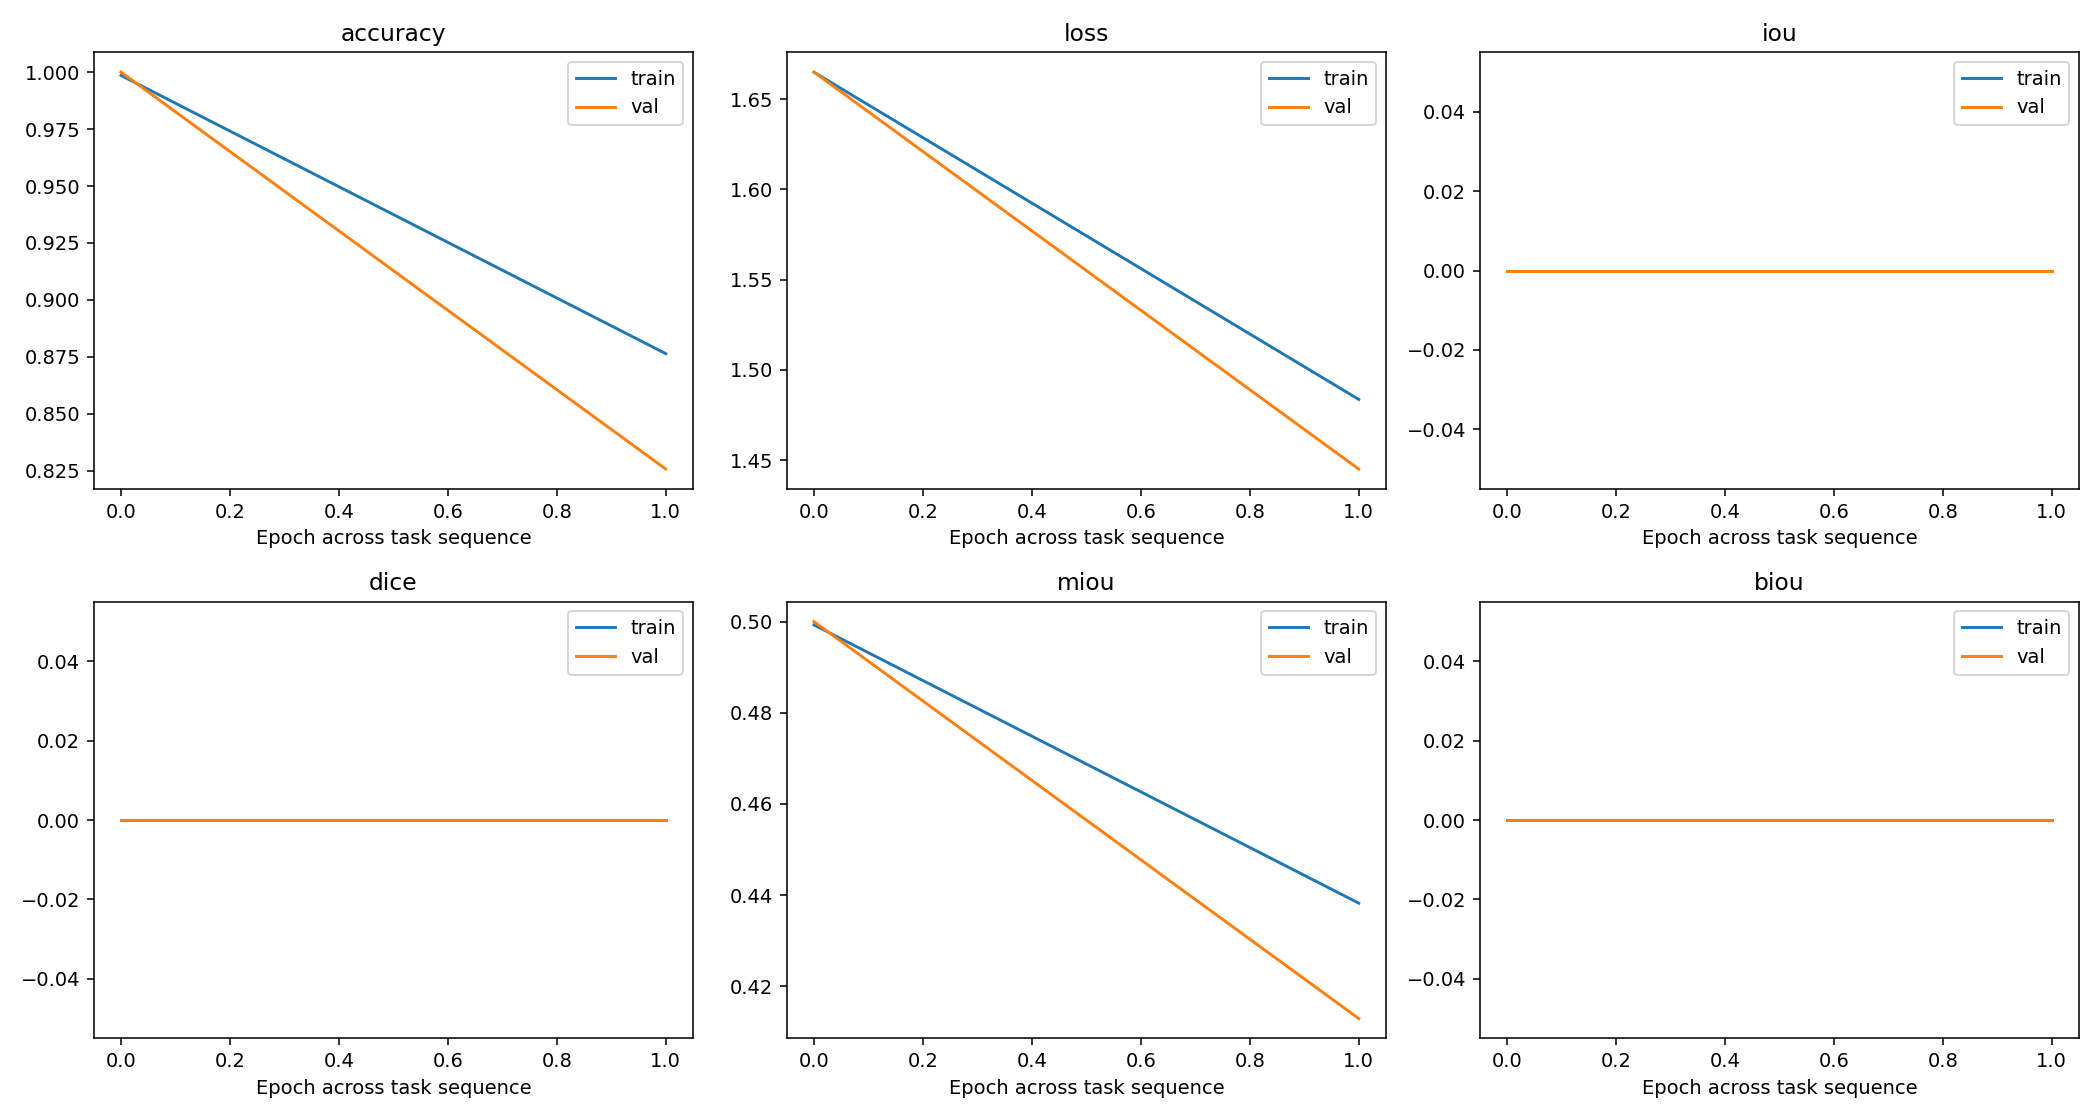

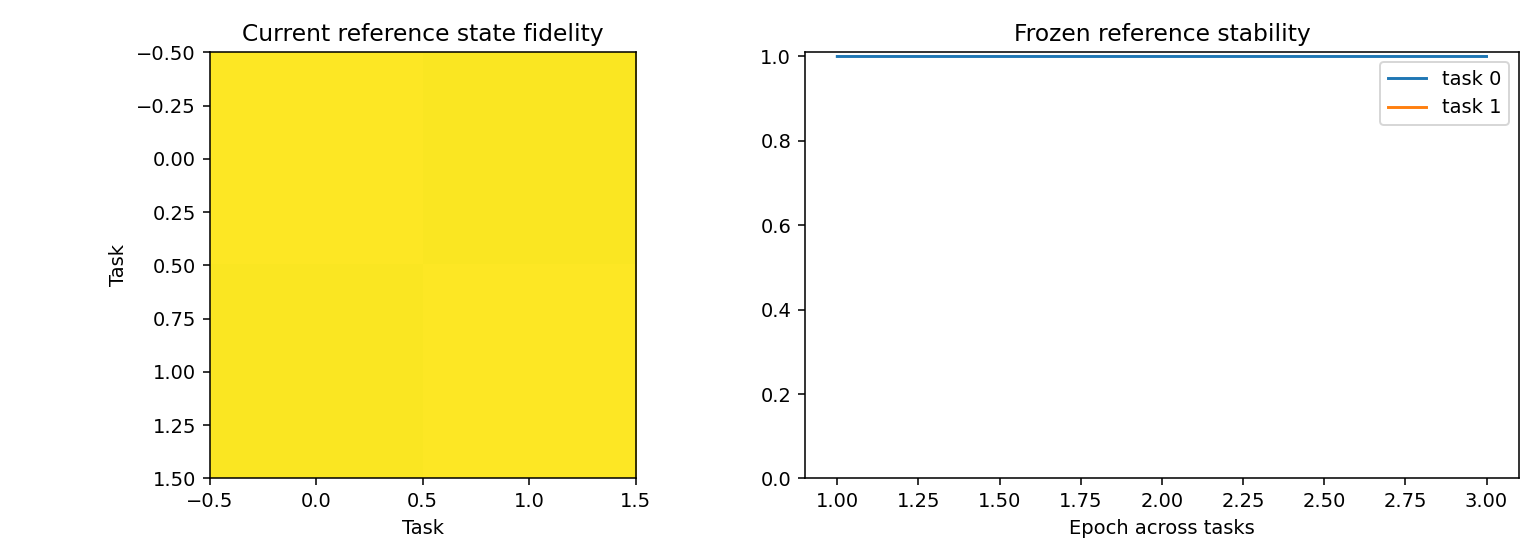

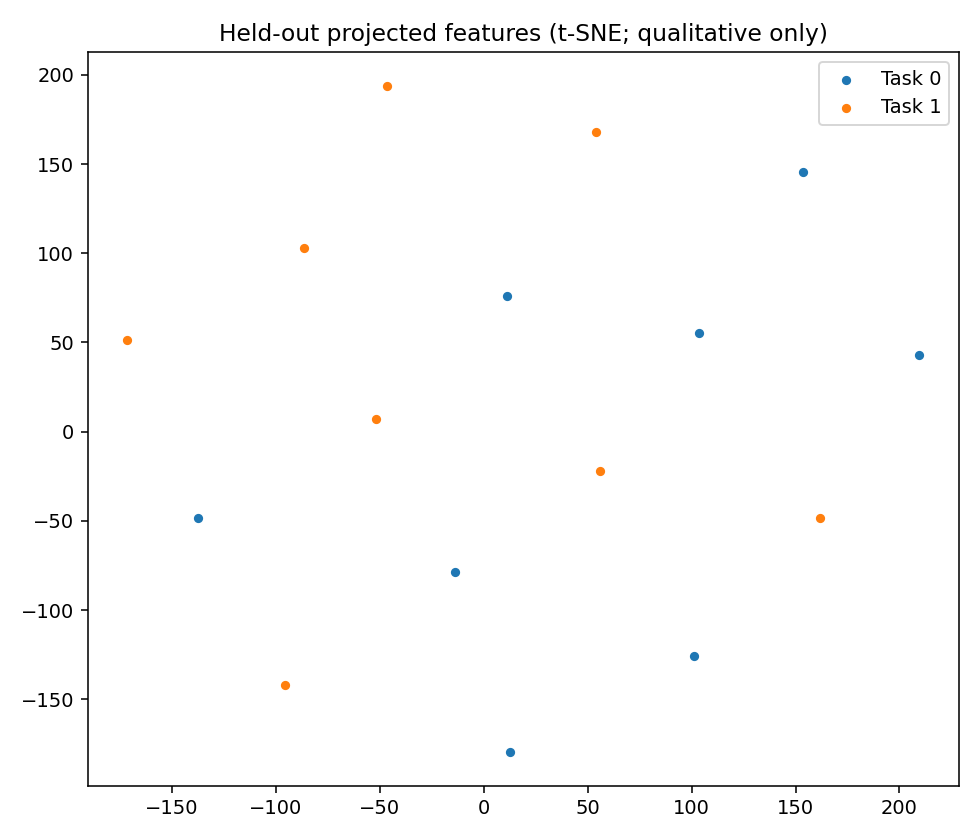

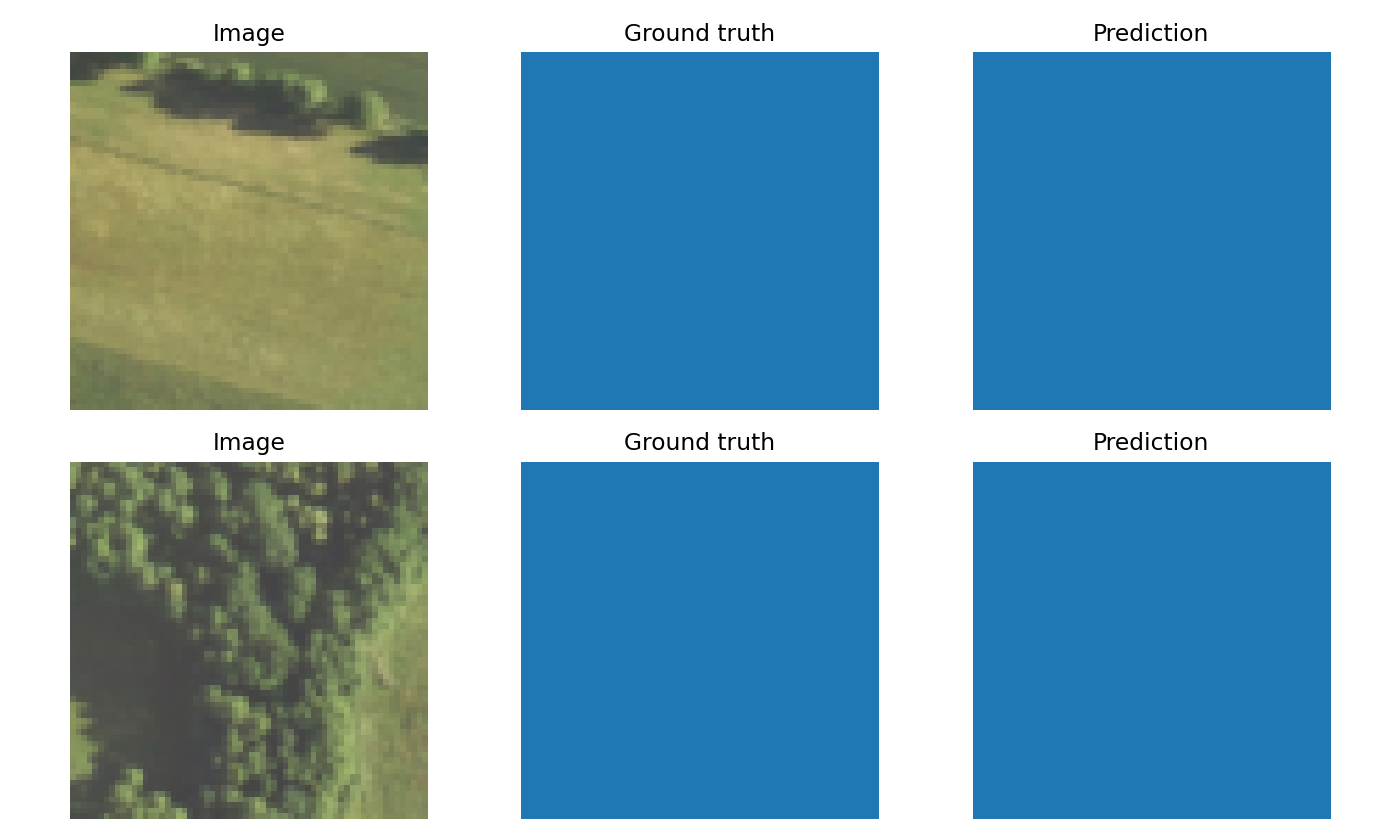

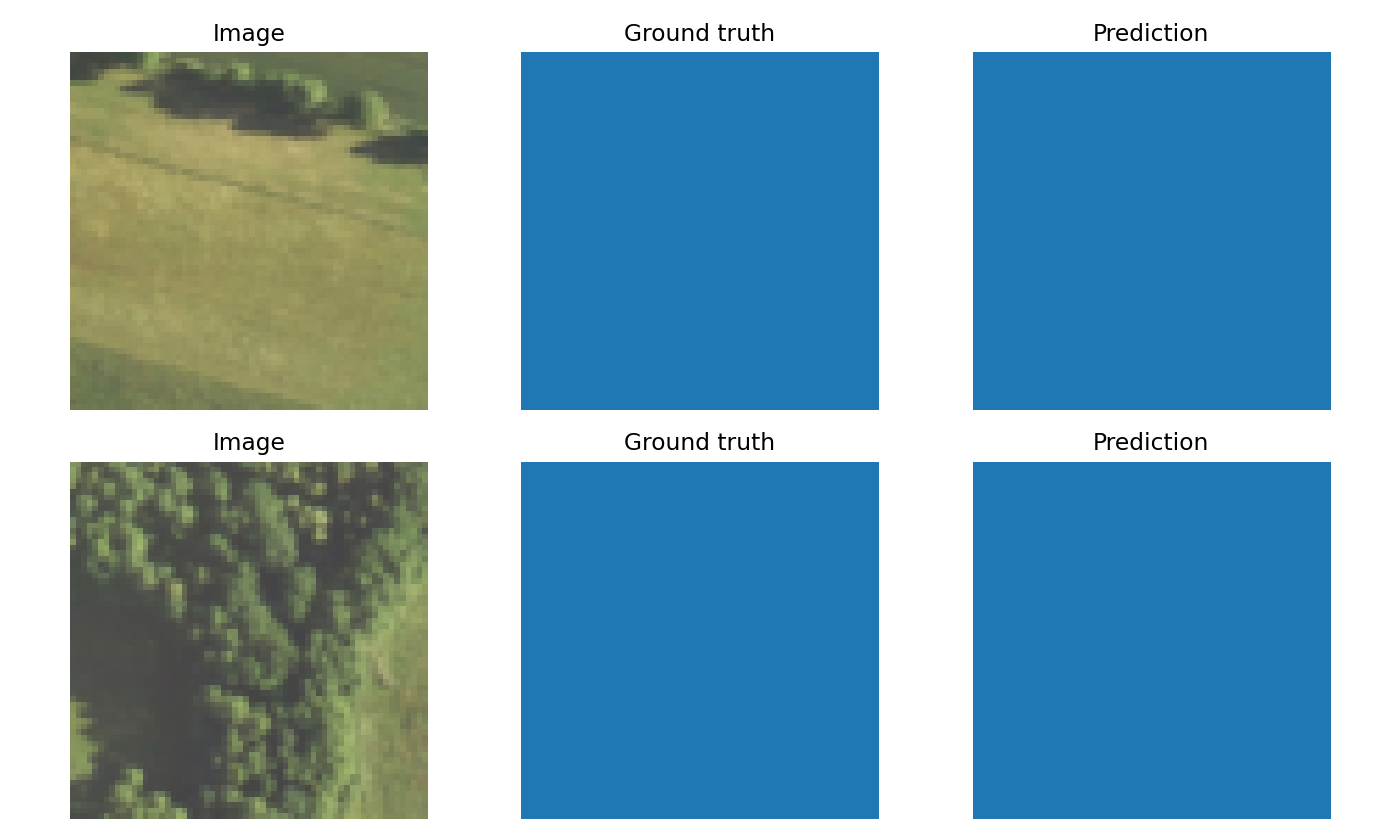

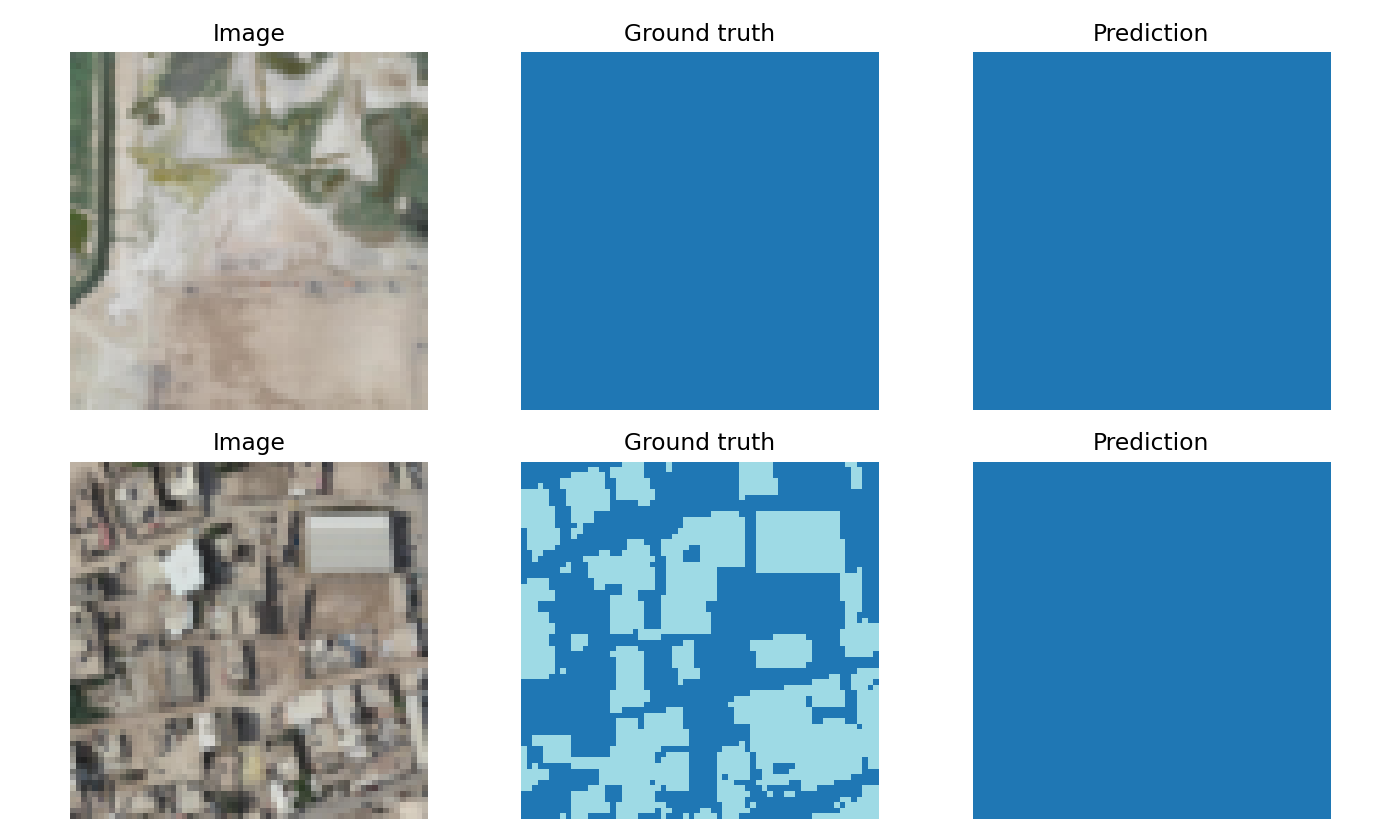

In [4]:
from IPython.display import display, Image
OUT = Path(cfg['output_dir'])
display(json.loads((OUT / 'summary.json').read_text()))
display(json.loads((OUT / 'test_iou_matrix.json').read_text()))
for name in ['learning_curves.png', 'overlap_stability.png', 'tsne.png']:
    if (OUT / name).exists():
        display(Image(filename=str(OUT / name)))
for path in sorted(OUT.glob('after_*_predictions.png')):
    display(Image(filename=str(path)))


## Optional: resume a completed task boundary
Checkpoints include model, references, replay samples, prototypes, split fingerprints and history. Resume restarts at the next task; interruption inside a task reruns that task from the prior completed boundary. Use the original config. Run directories and source manifests must remain available.


In [5]:
# checkpoint = OUT / 'task_0_complete.pt'
# summary = run(cfg, resume=checkpoint)


## Optional: toy controls, baseline ladder and DGX
These are explicit experiments; leave commented until needed. Full baseline comparisons require the same data protocol and at least three seeds. Oracle/router segmentation outputs coincide in this task-independent forward architecture; router task classification is reported separately.


In [6]:
# from tqsi.experiments import toy, ladder, generate_ablations
# toy(output='outputs/toy', steps=50)
# ladder('configs/dgx.yaml', output='outputs/ladder')
# generate_ablations('configs/dgx.yaml', 'configs/generated')
# import subprocess
# subprocess.run(['bash', 'scripts/launch_dgx.sh', 'configs/dgx.yaml'], check=True)
